In [1]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = ""
import numpy as np, torch, torch.nn as nn
from qp_continuous import ContinuousQP
from qp_continuous_ar import Account, shares, plot_shares, plot_curves

d, p, n_days = 12, 6, 6            # assets, market features, training days
lam, sigma   = 1.3, 0.15           # the optimizer's risk aversion, the size of the learner's nudges

rng = np.random.default_rng(0)
X = rng.standard_normal((n_days, p))                                                  # features, one row per day
true_returns = 1 / (1 + np.exp(-2 * X @ rng.standard_normal((d, p)).T / np.sqrt(p)))   # hidden: what the model must learn
F = rng.standard_normal((d, d // 2)) / np.sqrt(d // 2)
Sigma = F @ F.T + 0.25 * np.eye(d)                                                    # hidden: how the assets co-move

In [2]:
Sinv = np.linalg.inv(Sigma); u = Sinv @ np.ones(d)
M, b0 = (Sinv - np.outer(u, u) / u.sum()) / lam, u / u.sum()      # optimizer: portfolio(c) = M c + b0

def value(day, z):                                                # what a portfolio is really worth that day
    return true_returns[day] @ z - lam / 2 * z @ Sigma @ z
best  = [value(i,  M @ true_returns[i] + b0) for i in range(n_days)]
worst = [value(i, -M @ true_returns[i] + b0) for i in range(n_days)]

def black_box(day, predicted_returns):                            # regret: 0 = best possible, 1 = worst
    return (best[day] - value(day, M @ predicted_returns + b0)) / (best[day] - worst[day])

box = ContinuousQP.from_data(X, true_returns, Sigma, lam=lam, sigma=sigma)   # the same box, for the exact critic

In [3]:
class Model(nn.Module):
    def __init__(self, h=8, pos_scale=0.1, train_pos=False, seed=0):
        super().__init__(); torch.manual_seed(seed)
        self.trunk, self.head = nn.Linear(p, h), nn.Linear(h, 1)          # shared by all assets
        pos = torch.randn(d, h) * pos_scale                                 # one code per asset
        if train_pos: 
            self.pos = nn.Parameter(pos)                          # private and trainable
        else:
            self.register_buffer("pos", pos)                      # fixed
        nn.init.zeros_(self.head.weight); nn.init.zeros_(self.head.bias)    # start by predicting 0 for every asset

    def forward(self, x):                                                   # features (..., p) -> returns (..., d)
        return self.head(torch.tanh(self.trunk(x).unsqueeze(-2) + self.pos)).squeeze(-1)

shared = lambda seed: Model(h=8,  pos_scale=0.1, train_pos=False, seed=seed)
private = lambda seed: Model(h=32, pos_scale=1.0, train_pos=True,  seed=seed)

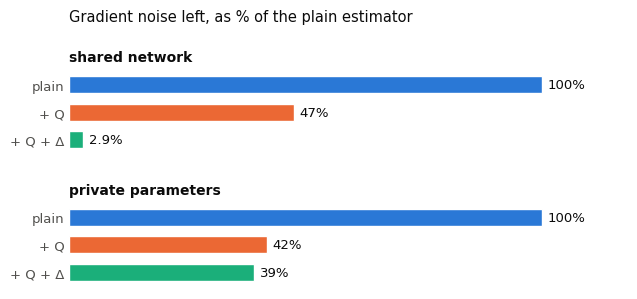

In [4]:
plot_shares({"shared network": shares(box, shared),
             "private parameters": shares(box, private)});

Q alone removes about half of the noise. Δ removes almost all of the rest — but only for the shared network. With private parameters per asset, the leftover noise has no common direction and Δ has nothing to cancel. **The model's design decides whether Δ can work.**

In [ ]:
Xt = torch.as_tensor(X, dtype=torch.float32)
baseline, surrogates = {}, {}                                  

def plain(model, day, seed):                                  
    mu = model(Xt[day])
    nudged = mu.detach() + sigma * torch.randn(d)             
    score = black_box(day, nudged.numpy())                  
    b = baseline.get(day, score); baseline[day] = 0.9 * b + 0.1 * score    # running average to compare against
    log_prob = -((nudged - mu) ** 2).sum() / (2 * sigma ** 2)
    grads = torch.autograd.grad((score - b) * log_prob, list(model.parameters()))
    return torch.cat([g.flatten() for g in grads])

with_q = lambda model, day, seed: Account(box, model, day).mc("prefix", None,  N=1, seed=seed)[0]
with_q_delta = lambda model, day, seed: Account(box, model, day).mc("prefix", "pre", N=1, seed=seed)[0]
exact = lambda model, day, seed: box.true_grad(model, day)

def train(make_model, gradient, calls=1600, lr=0.01, seed=0, every=50, K=1):     # K: calls to the black box per step
    model = make_model(seed); opt = torch.optim.Adam(model.parameters(), lr=lr); baseline.clear(); surrogates.clear(); log = []
    for step in range(0, calls + 1, K):
        if len(log) <= step // every: 
            log.append(box.regret(model))    # exact regret, for the plot only
        if step == calls: 
            break
        g = gradient(model, (step // K) % n_days, seed * 100000 + step)  # one step: K calls to the black box
        opt.zero_grad(); k = 0
        for prm in model.parameters():
            prm.grad = g[k:k + prm.numel()].view_as(prm).float(); k += prm.numel()
        opt.step()
    return log

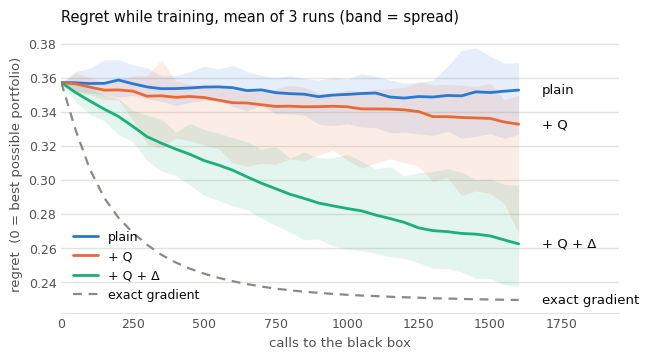

In [6]:
methods = {"plain": plain, "+ Q": with_q, "+ Q + Δ": with_q_delta, "exact gradient": exact}
runs = {name: np.array([train(shared, g, seed=s) for s in range(10)]) for name, g in methods.items()}
plot_curves(np.arange(0, 1601, 50), runs);

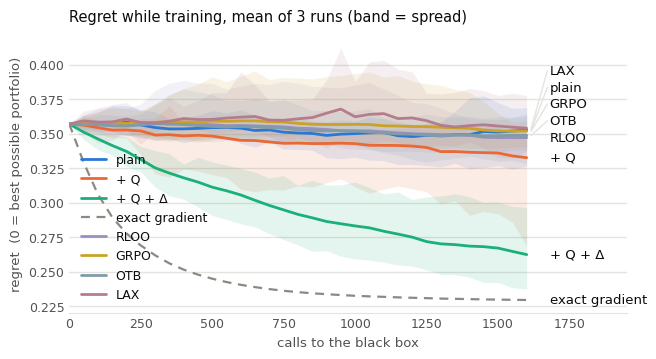

In [7]:
import sys; sys.path.insert(0, ".."); from baselines import group_weights, lax_weights, Surrogate
K = 4                                                                     # group size: nudged predictions per step

def nudge(model, day, seed, n):                                          # n nudged predictions and their scores
    J, mu = (x.float() for x in box.jac(model, day))                      # J[j] = d mu_j / d theta, the direction of coordinate j's score
    b = mu + sigma * torch.randn(n, d, generator=torch.Generator().manual_seed(seed))
    return J, mu, b, torch.tensor([black_box(day, x.numpy()) for x in b], dtype=torch.float32)

def grouped(method):                                                      # RLOO, GRPO, OTB: one advantage per nudge (per coordinate for OTB)
    def gradient(model, day, seed):
        J, mu, b, f = nudge(model, day, seed, K)
        return group_weights(method, f, (b - mu) / sigma ** 2, torch.arange(d).expand(K, d), (J * J).sum(1)) @ J
    return gradient

def lax(model, day, seed):                                                # LAX: a surrogate c_phi(b) per day, fitted as it goes
    J, mu, b, f = nudge(model, day, seed, 1)
    if day not in surrogates: surrogates[day] = Surrogate(d)
    w = lax_weights(surrogates[day], mu, b, f, sigma); g = w.detach() @ J
    surrogates[day].fit(w, J @ J.T)
    return g

seeds = range(len(runs["plain"]))
more = {name: np.array([train(shared, grouped(name), seed=s, K=K) for s in seeds]) for name in ("RLOO", "GRPO", "OTB")}
more["LAX"] = np.array([train(shared, lax, seed=s) for s in seeds])
plot_curves(np.arange(0, 1601, 50), {**runs, **more});